<h1 style="font-size: 1.6rem; font-weight: bold">ITO 5217: Natural Language Processing</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Module 3.2: Recurrent Neural Networks</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

### **Feedforward Neural Networks Language Models (NNLM)**

So far we have used neural networks for classification tasks like sentiment analysis. Now we turn to a different problem, **language modelling**: given theprevious words in a sentence, how likely is the next word?

Traditional count-based N-gram models struggle with this because they can only generalise to word sequences they have seen before. NNLMs solve this by learning **continuous word representations**, dense vectors that capture meaning, which allow the model to generalise to unseen word combinations far more effectively.

<br>

#### **The Architecture of Neural Networks Language Models (NNLM)**

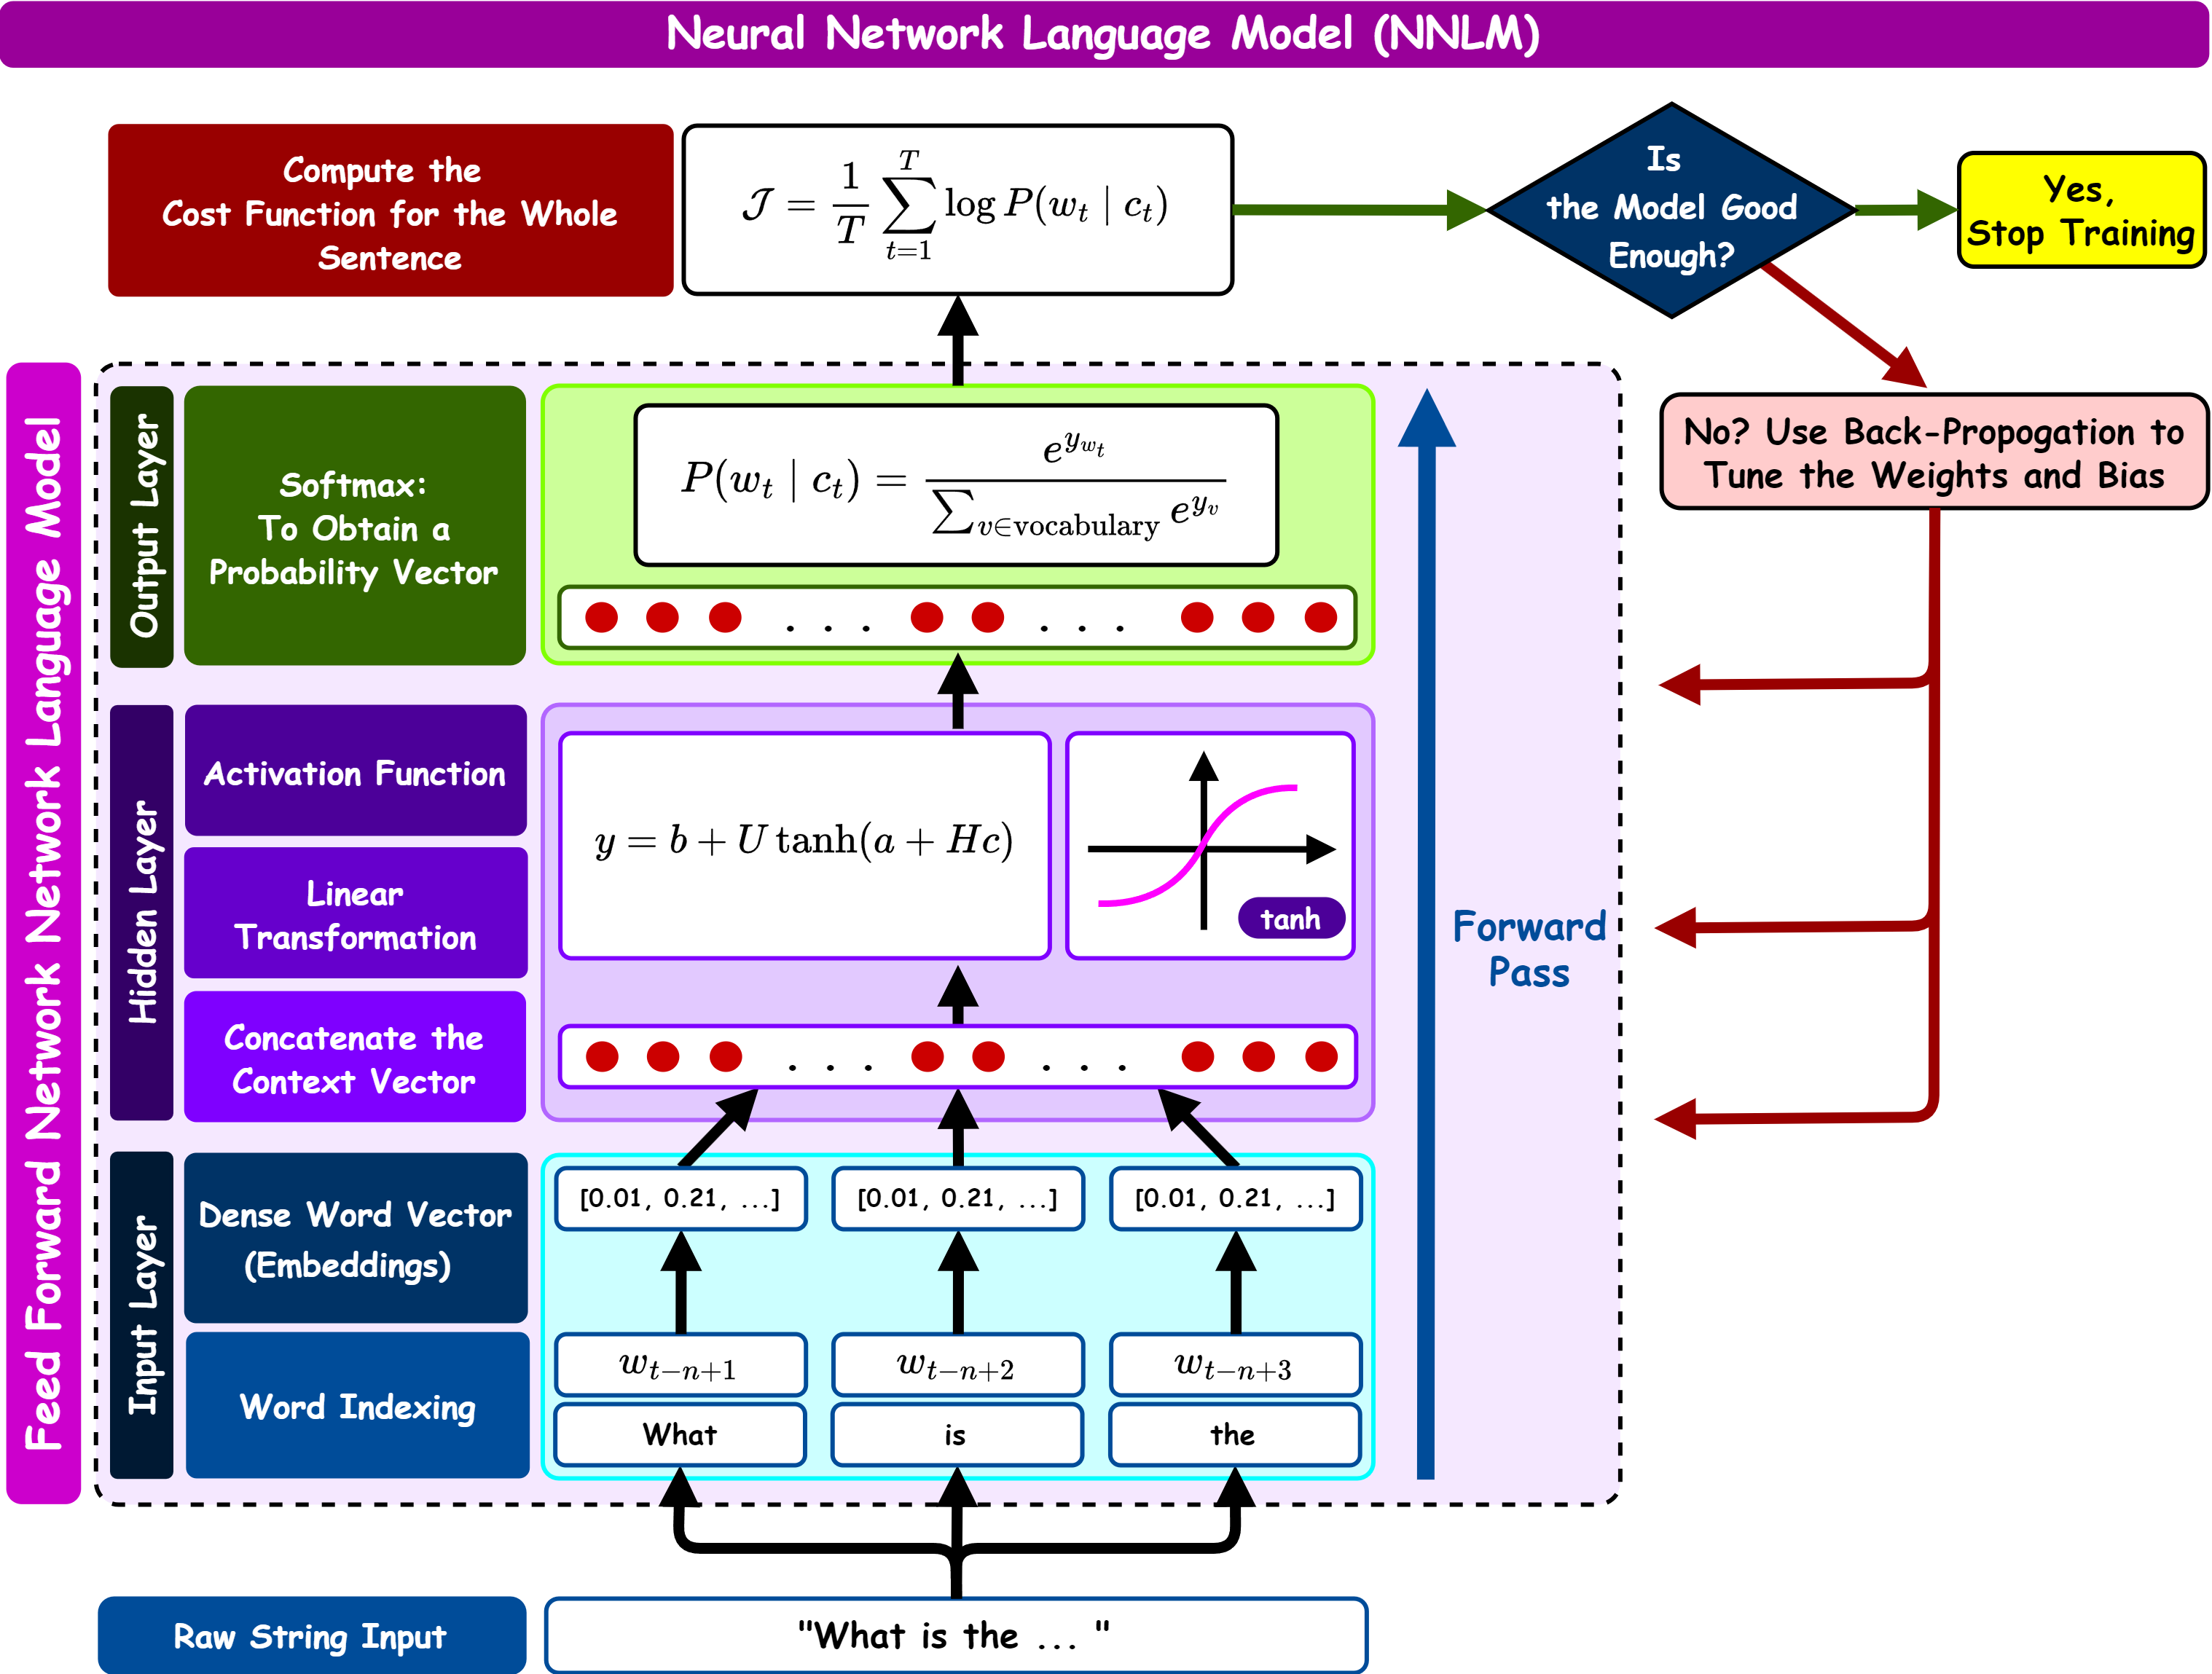

The goal of an NNLM is to predict the next word $w_t$ given the previous $n-1$, context words. Working from the bottom of the network upward:

**Step 1 Input: Context Word Indexes**

The previous $n-1$ words are represented as indexes into the vocabulary:

$$w_{t-n+1}, \quad w_{t-2}, \quad w_{t-1}$$

**Step 2 Lookup: Dense Word Vectors**

Each index is mapped to a **dense vector** (also called a word embedding), a compact, continuous representation of that word learned during training. This is fundamentally different from one-hot vectors, which are sparse and treat every word as completely unrelated to every other word.

**Step 3 Concatenate, Transform and Activation Function (Forward Pass Equation)**

All context word vectors are concatenated into a single vector and passed through one or more hidden layers with non-linear activations, allowing the network to learn complex interactions between the context words. The entire forward pass of the NNLM can be expressed in a single equation. This combines the linear transformation and activation function of the hiddenlayer, and the linear transformation of the output layer all in one line:

$$y = b + U\tanh(a + Hc)$$

**Step 4 Softmax Output**

The final hidden layer output is passed through a **softmax** function to produce a probability distribution over the entire vocabulary:

$$P(w_t = i \mid \text{context})$$

The $i$-th output value is the probability that the next word is the $i$-th word in the vocabulary. The output vector has one entry per word in the vocabulary, and all entries sum to 1.

<br>

#### **The Forward Pass Equation**

The entire forward pass of the NNLM can be expressed in a single equation. This combines the linear transformation and activation function of the hiddenlayer, and the linear transformation of the output layer all in one line:

$$y = b + U\tanh(a + Hc)$$

Where:
- $c$ = the concatenated context word embeddings (the input)
- $H$ = weight matrix connecting the input to the hidden layer
- $a$ = bias term for the hidden layer
- $a + Hc$ = linear transformation of the input
- $\tanh(a + Hc)$ = activation function applied to the linear transformation, producing the hidden layer $h$
- $U$ = weight matrix connecting the hidden layer to the output
- $b$ = bias term for the output layer
- $y$ = the final raw output scores, one per word in the vocabulary

Breaking it down step by step:

| Step | Expression | What it does |
|---|---|---|
| 1 | $c$ | Concatenated word embeddings fed in as input |
| 2 | $a + Hc$ | Linear transformation — weighted sum plus bias |
| 3 | $\tanh(a + Hc)$ | Activation function — adds non-linearity, produces hidden layer $h$ |
| 4 | $b + U\tanh(a + Hc)$ | Second linear transformation — projects hidden layer to output scores |
| 5 | $y$ | Raw scores fed into softmax to produce probabilities |

Note that $\tanh$ is used here instead of sigmoid as the hidden layer activation function. Tanh outputs values between $-1$ and $+1$ (compared to sigmoid's $0$ to $1$), which works better in practice because it is zero-centred, meaning the gradients flow more evenly during backpropagation, making training faster and more stable.

#### **The Softmax Function**

Softmax is a mathematical trick that converts any vector of raw scores into a valid probability distribution — all values become positive and sum to 1. For each word $v$ in the vocabulary, the probability of the next word being $w_t$ given the context $c_t$ is:

$$P(w_t \mid c_t) = \frac{e^{y_{w_t}}}{\sum_{v \in \text{vocabulary}} e^{y_v}}$$

More explicitly, given context words $w_{t-n+1} \ldots w_{t-1}$:

$$P(w_t \mid w_{t-n+1} \ldots w_{t-1}) = \frac{e^{y_{w_t}}}{\sum_{v \in \text{vocabulary}} e^{y_v}}$$

The intuition is simple, **exponentiate** each score to make it positive, then **divide by the sum** of all exponentiated scores to normalise into probabilities. A higher raw score for a word means a higher probability of being the next word.

<br>

#### **Training the NNLM**

Training follows the same forward-backward pattern as before. The objective is to maximise the average log probability of the correct next word across all positions $t$ in the training corpus of length $T$:

$$\mathcal{J} = \frac{1}{T} \sum_{t=1}^{T} \log P(w_t \mid c_t)$$

1. **Forward pass** feed the context words through the network and compute
$P(w_t \mid c_t)$ using softmax
2. **Backward pass** backpropagate the error and update all parameters
including the word embedding vectors themselves

<br>

#### **Dense Word Representations**

A useful byproduct of training an NNLM is that the word embedding matrix learnedd uring training captures meaningful relationships between words. Words that appear in similar contexts end up with similar vectors, so the model implicitly learns that "cat" and "dog" are more related to each other than either is to "democracy", purely from seeing them used in similar ways in the training data.

| Feature | Count-based N-grams | NNLM |
|---|---|---|
| Word representation | Sparse, discrete indexes | Dense, continuous vectors |
| Generalisation | Only seen sequences | Can generalise to unseen combinations |
| Context captured | Fixed window of counts | Learned interactions via hidden layers |
| Bonus output | None | Reusable word embeddings |

---

### **Recurrent Neural Networks (RNNs) and language models**

A Feedforward NNLM can only look at a **fixed window** of previous words as context. This is limiting — what if the context needed to predict the next word is much further back in the sentence? RNNs solve this by introducing a **memory mechanism** that carries information from every previous time step forward, allowing the model to theoretically use the entire history of words seen so far.

<br>

#### **The Key Idea: Recurrence**

The defining feature of an RNN is that each cell takes **two inputs** instead of one:

1. The **current word** $x_t$ — via weight matrix $U$
2. The **previous hidden state** $h_{t-1}$ — via weight matrix $W$

This means the hidden state $h_t$ is not just a function of the current word, it is a function of the current word **and everything that came before it**. The hidden state acts as the network's **memory**.

$$h_t = \sigma(Ux_t + Wh_{t-1})$$

Where:
- $x_t$ = word embedding of the current word at time step $t$
- $U$ = weight matrix connecting the input to the hidden layer
- $h_{t-1}$ = hidden state from the previous time step
- $W$ = weight matrix connecting the previous hidden state to the current cell
- $\sigma$ = activation function (e.g. tanh or sigmoid)
- $h_t$ = the new hidden state — updated memory of everything seen so far

For the very first time step $t=1$, there is no previous hidden state, so $h_{t-1}$ is initialised as a **vector of zeros** — essentially saying the network starts with no memory.

<br>

#### **The Architecture: Layer by Layer**

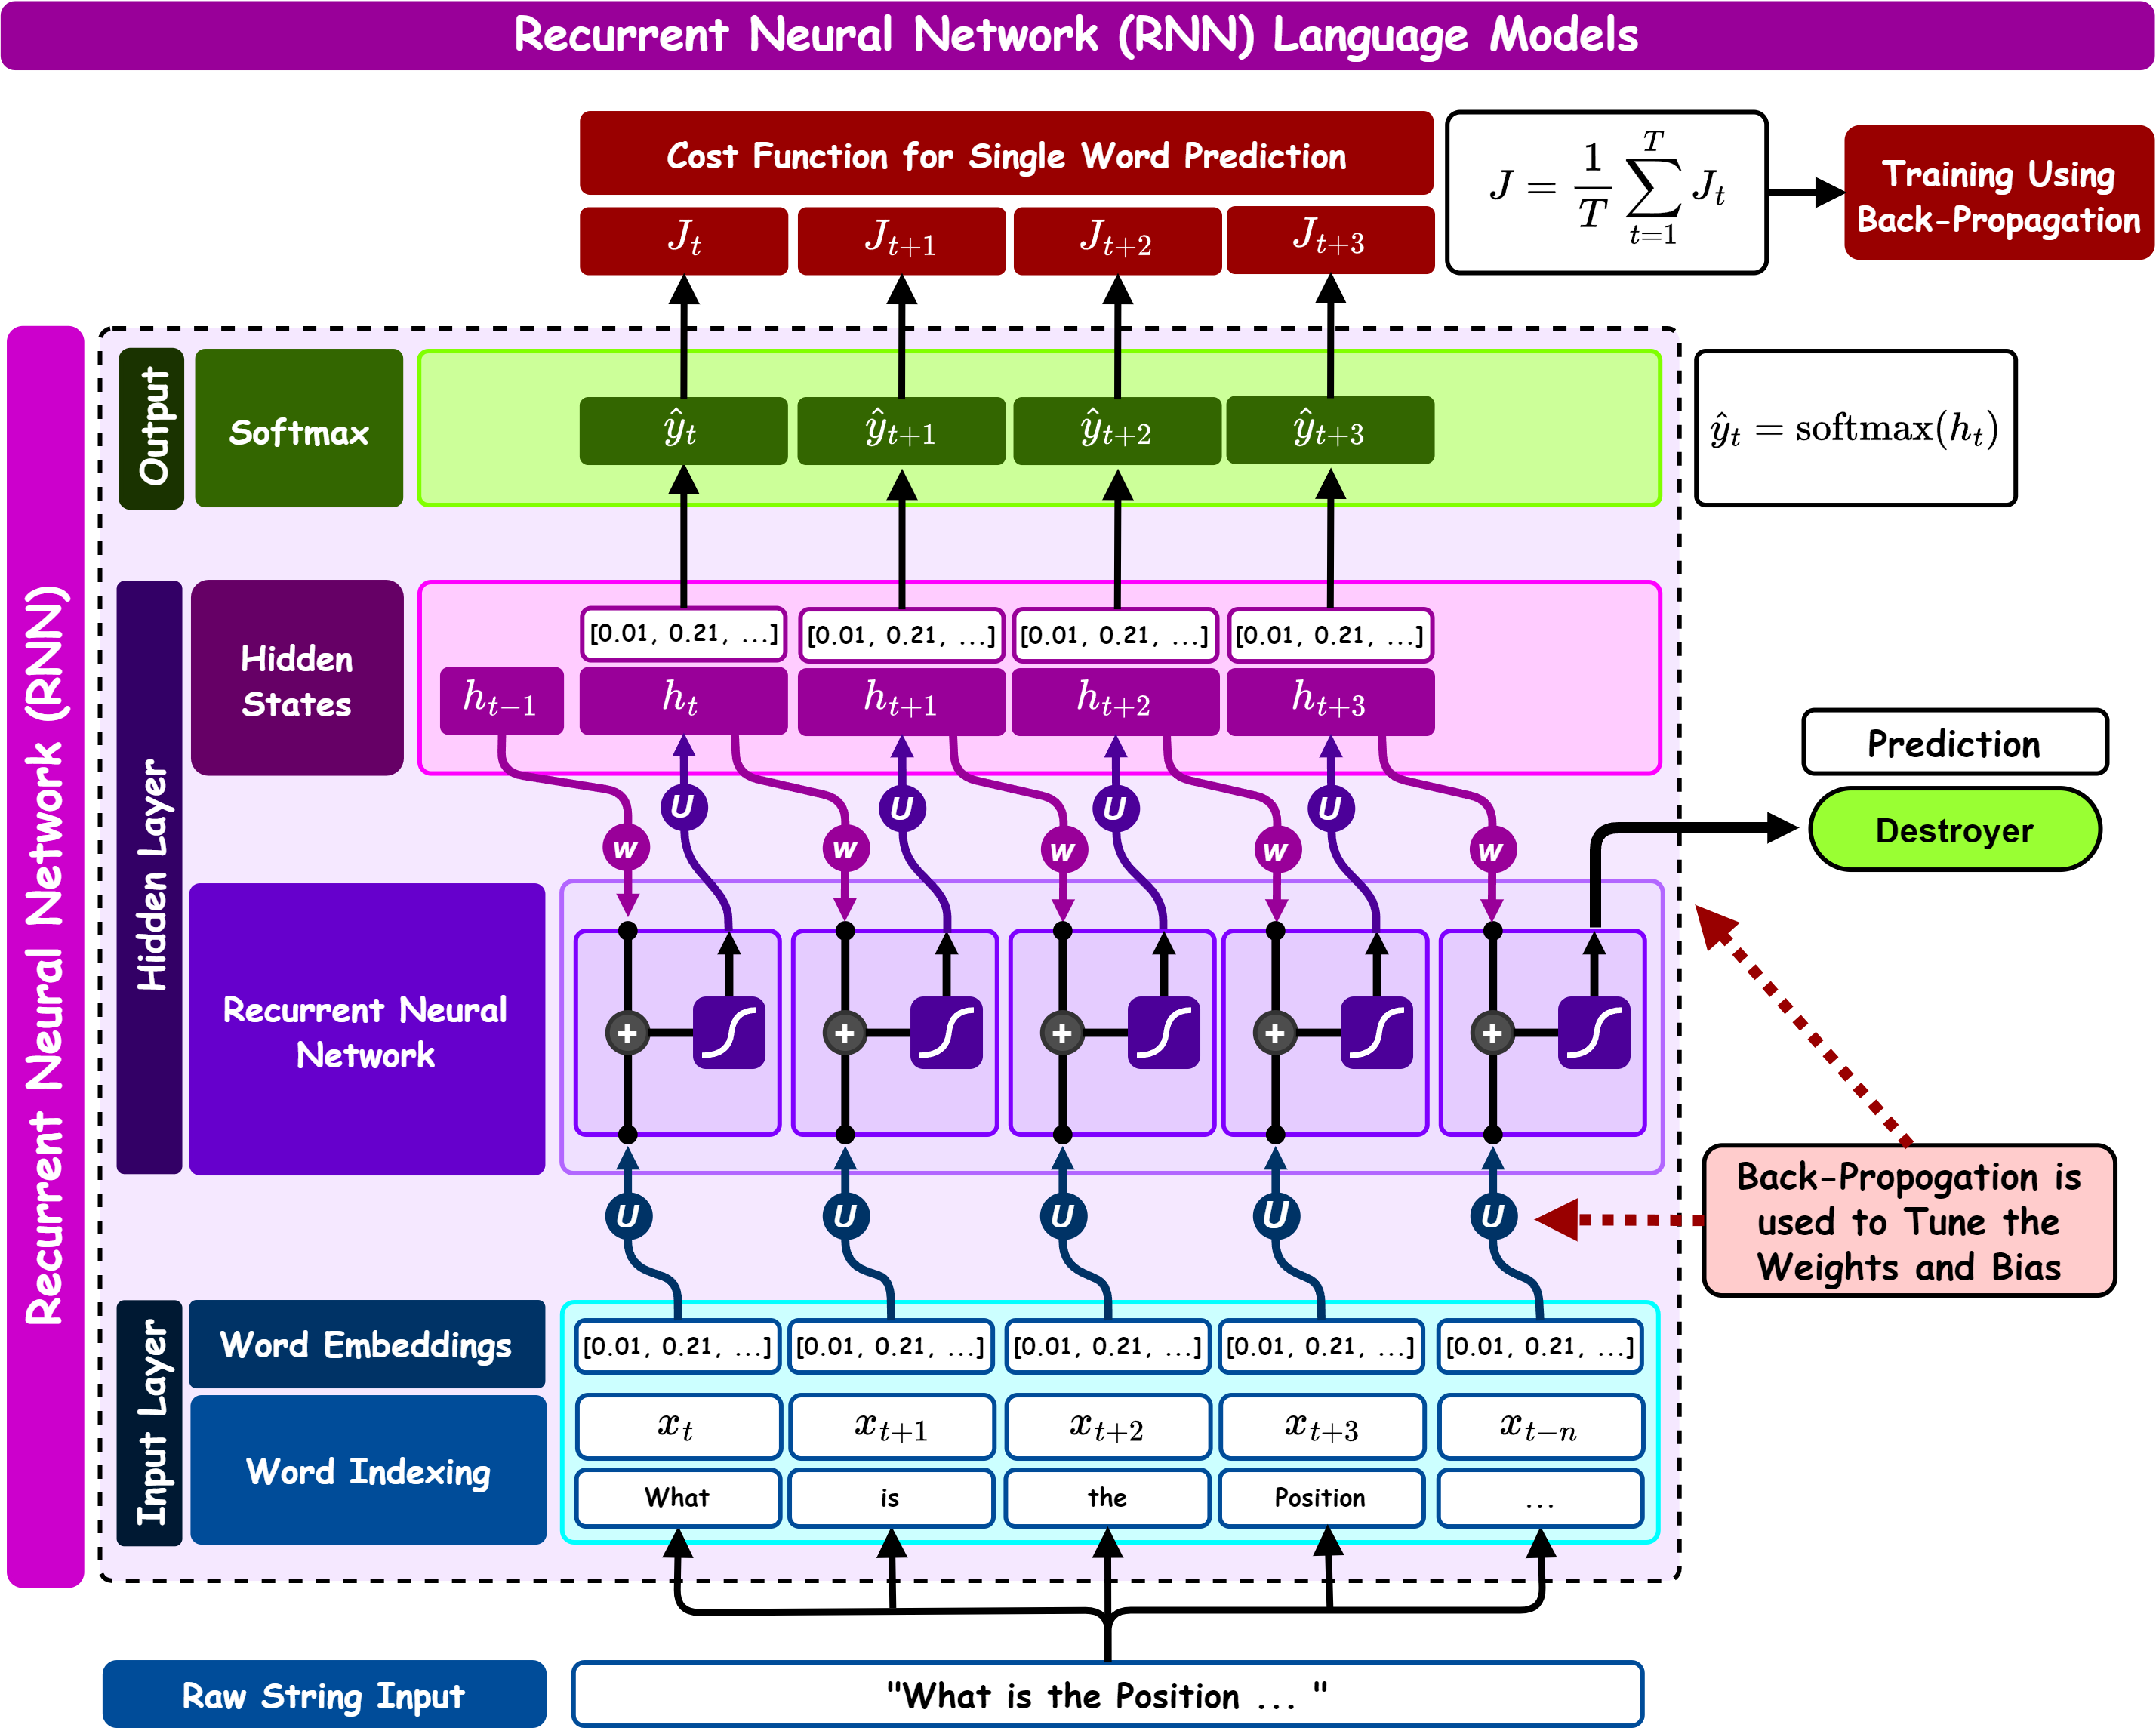

Working from the bottom of the diagram upward:

**Input Layer**

The raw string input is first converted into word indexes, then each index is mapped to a dense word embedding vector $[0.01, 0.21, ...]$. This is identical to the NNLM, each word becomes a continuous vector representation:

$$x_t, x_{t+1}, x_{t+2}, x_{t+3} \ldots x_{t-n}$$

**Hidden Layer: Recurrent Neural Network**

Each RNN cell receives the current word embedding via $U$ and the previous hidden state via $W$, adds them together, and passes the result through an activation function $\sigma$:

$$h_t = \sigma(Ux_t + Wh_{t-1})$$

The hidden state $h_t$ is a dense vector $[0.01, 0.21, ...]$ that encodes everything the network has seen up to and including time step $t$. This hidden state is then passed both **upward** to the output layer and **sideways** to the next RNN cell as $h_{t-1}$.

**Output Layer: Softmax**

Each hidden state $h_t$ is passed through a softmax function to produce a probability distribution $\hat{y}_t$ over the entire vocabulary:

$$\hat{y}_t = \text{softmax}(h_t)$$

This gives the probability of every word in the vocabulary being the next word at each time step $t$.

<br>

#### **Cost Function**

Since the RNN makes a prediction at **every single time step**, there is an individual loss $J_t$ for each prediction — the negative log probability of the correct word at that position:

$$J_t = -\log P(w_t \mid w_1 \ldots w_{t-1})$$

The total cost function $J$ is then the average of all individual losses across the entire sequence of length $T$:

$$J = \frac{1}{T} \sum_{t=1}^{T} J_t$$

So for a sentence like "What is the Position ...":

| Time step | Input | Prediction $\hat{y}_t$ | Loss $J_t$ |
|---|---|---|---|
| $t$ | What | probability over vocabulary | $-\log P(\text{is} \mid \text{What})$ |
| $t+1$ | is | probability over vocabulary | $-\log P(\text{the} \mid \text{What is})$ |
| $t+2$ | the | probability over vocabulary | $-\log P(\text{Position} \mid \text{What is the})$ |
| $t+3$ | Position | probability over vocabulary | $-\log P(\ldots \mid \text{What is the Position})$ |

<br>

#### **Training: Backpropagation Through Time**

Training follows the same forward-backward pattern as before, but because the RNN processes sequences, backpropagation has to travel **backwards through time** — propagating gradients from the last time step all the way back to the first:

1. **Forward pass** — process each word one at a time, computing $h_t$ and
$\hat{y}_t$ at each step
2. **Compute loss** — calculate $J_t$ at each time step, then average into $J$
3. **Backward pass** — backpropagate the error backwards through every time step
to update $U$, $W$, and the word embeddings

The same weights $U$ and $W$ are **shared across all time steps**, the network does not learn separate weights for each position in the sequence. This is what keeps the number of parameters manageable regardless of sequence length.

<br>

#### **RNN vs NNLM: Key Differences**

| | NNLM (Feedforward) | RNN Language Model |
|---|---|---|
| Context window | Fixed — last $n$ words only | Unlimited — all previous words |
| Memory | None — each prediction is independent | Hidden state carries memory forward |
| Weights | Separate weights per position | **Shared** weights $U$ and $W$ across all steps |
| Cost function | $\mathcal{J} = \frac{1}{T}\sum \log P(w_t \mid c_t)$ | $J = \frac{1}{T}\sum J_t$ |
| Softmax | Once at the end | Once **per time step** |
| Handles long sentences | Poorly | Much better |

---

### **Word2Vec & Skip-Gram**

**Word2Vec** is a shallow feedforward neural network that learns word representations by training on large amounts of text. The core idea is simple, words that appear in similar contexts should have similar vector representations. After training, similar words like "apricot" and "mango" end up close together in vector space, while unrelated words like "apricot" and "aardvark" end up far apart.

#### **The Skip-Gram Model**

The **skip-gram** model frames word learning as a classification problem — given
a target word $w(t)$, predict the words likely to appear nearby within a defined
window size. For example with window size 2:
```
"The quick brown fox jumps..."
          ↑
       brown  →  predicts: The, quick, fox, jumps
```

Training pairs are created by sliding this window across the entire corpus,
generating (target word, context word) pairs:

| Target | Context |
|---|---|
| brown | the, quick, fox, jumps |
| fox | quick, brown, jumps, over |

#### **Positive & Negative Examples**

Training uses both positive and negative examples:

- **Positive examples** — real (target, context) pairs from the corpus e.g.
(apricot, jam), (apricot, recipe)
- **Negative examples** — randomly sampled word pairs that do not appear
together e.g. (apricot, aardvark), (apricot, coaxial)

This forces the model to learn what words genuinely co-occur versus what words
are simply random noise.

<br>

#### **Architecture & Math**

The skip-gram network has three steps:

1. **Input** — one-hot vector representing the target word $w(t)$
e.g. 'apricot' = $[0,0,1,0,0,0]$

2. **Projection** — linear transformation via embedding weight matrix $E$
($d \times |V|$) — this is where the dense word vector lives

3. **Output** — softmax converts scores into a probability distribution over
the vocabulary:

$$P(v \mid w) = \frac{e^{y_v}}{\sum_{u \in \text{vocabulary}} e^{y_u}}$$

This gives the probability that word $v$ appears in the context of word $w$.

<br>

#### **Dense Word Representations**

The real output of Word2Vec is not the predictions themselves — it is the
**embedding weight matrix** $E$ learned during training. Each row of $E$
is a dense vector representation of one word, capturing its meaning through
the contexts it appeared in.

| | One-Hot | Word2Vec Embedding |
|---|---|---|
| Representation | $[0,0,1,0,0...]$ sparse | $[0.2, -0.5, 0.8...]$ dense |
| Similar words | Always equally different | Close together in vector space |
| Learned? | No | Yes — from context |
| Size | Vocabulary size | Small fixed size (e.g. 100-300) |